# Gap-filling head time series using Pastas

*Raoul Collenteur, Hydroconsult, 2026*

In [21]:
import pandas as pd
import pastas as ps

ps.show_versions()

Pastas     : 2.0.0
Python     : 3.13.5
Numpy      : 2.2.6
Pandas     : 2.3.3
Scipy      : 1.16.1
Matplotlib : 3.10.8
Numba      : 0.61.2



In [22]:
head = pd.read_csv(
    "data/head_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()

# Create a gap in the head data
head_gap = head.copy()
head_gap.loc["1996"] = pd.NA
head_gap = head_gap.dropna()

prec = pd.read_csv(
    "data/rain_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()
evap = pd.read_csv(
    "data/evap_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()

<Axes: xlabel='date'>

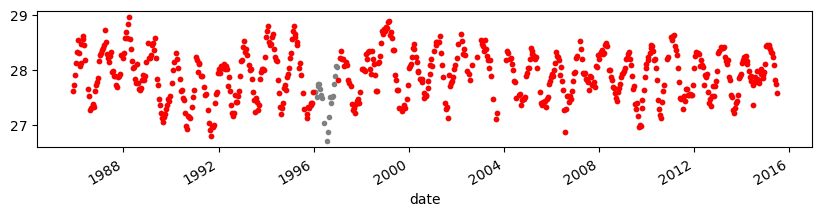

In [23]:
head.plot(marker=".", color="gray", linestyle="None", label="head", figsize=(10, 2))
head_gap.plot(marker=".", color="red", linestyle="None", label="head with gap")


In [24]:
ml = ps.Model(head_gap)
sm = ps.RechargeModel(prec=prec, evap=evap, rfunc=ps.Exponential(), name="rch")
ml.add_stressmodel(sm)
ml.solve()


Fit report head                     Fit Statistics
nfev     12                     EVP          93.51
nobs     623                    R2            0.94
noise    False                  RMSE          0.11
tmin     1985-11-14 00:00:00    AICc      -2756.77
tmax     2015-06-28 00:00:00    BIC       -2739.10
freq     D                      Obj           3.68
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.         No
solver   LeastSquares           weights         No

Parameters (4 optimized)
               optimal     initial  vary
rch_A       602.818347  215.674528  True
rch_a       165.666499   10.000000  True
rch_f        -1.549188   -1.000000  True
constant_d   28.157069   27.912729  True


<Axes: xlabel='date', ylabel='Head'>

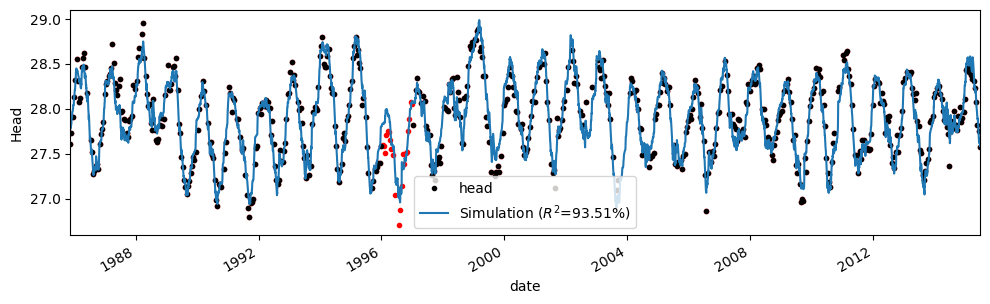

In [25]:
ax = ml.plot(figsize=(10, 3))
head.plot(marker=".", color="red", linestyle="None", label="head", ax=ax, zorder=-1)

In [26]:
head_filled = ps.gap_fill(
    head_gap.asfreq("D"), ml, tmin=head.index[0], tmax=head.index[-1]
)

<Axes: xlabel='date'>

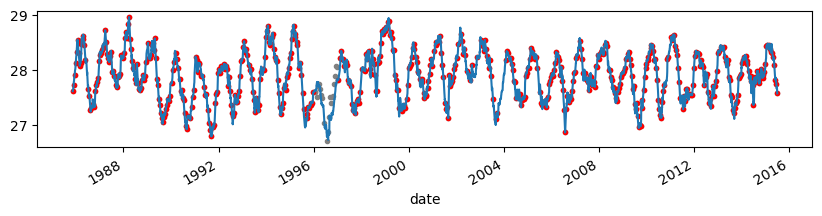

In [27]:
head.plot(marker=".", color="gray", linestyle="None", label="head", figsize=(10, 2))
head_gap.plot(marker=".", color="red", linestyle="None", label="head with gap")
head_filled.plot()